##**Project Name**    -   Facial Emotion Recognition Using Deep Learning




**Contribution**    - Individual  - **SARATHRAJ R**


## **Project Summary -**

**Introduction:**

The purpose of this project is to create a deep learning model capable of reliably categorizing facial expressions into seven categories: angry, disgusted, fearful, happy, sad, surprised, and neutral. We will train our model using convolutional neural networks (CNNs), which have been demonstrated to be effective in picture categorization tasks. Our technique entails creating a CNN model from scratch.

**Data:**

The FER-2013 dataset contains 48x48 pixel grayscale photographs of faces that have been automatically registered as centered and occupying a similar amount of space in each image. The dataset contains 24,400 photos, including 22,968 in the training set and 1,432 in the public test set.

**Preprocessing:**

In this part, we will use both data generators and data augmentation to train a deep learning model for detecting human emotions on the FER-2013 dataset. The dataset's size and complexity make it impractical to put all of the photos into memory at once. As a result, we will use data generators to generate batches of photos on the fly during training, allowing us to train our model efficiently on the full dataset.

In addition, we will use several data augmentation techniques on the training photos, including rotation, shifting, and flipping. This will help to expand the size and diversity of our training set, perhaps improving the performance of our deep learning model. Data augmentation can also help to prevent overfitting, which occurs when the model is overly fitted to the training set and performs badly on fresh, unknown data.

## **GitHub Link -**

Provide your GitHub Link here.

## **Problem Statement**


 Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

## **Installing Required Libraries**

In [1]:
!pip install tensorflow==2.15.0 keras==2.15.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [2]:
import tensorflow as tf
print(tf.__version__)

import keras
print(keras.__version__)

2.20.0
3.13.2


In [3]:
tf.__version__

'2.20.0'

In [4]:
keras.__version__

'3.13.2'

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!unzip "/content/drive/MyDrive/Face Emotion Recognition Dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: images/validation/fear/8797.jpg  
  inflating: images/validation/fear/8818.jpg  
  inflating: images/validation/fear/886.jpg  
  inflating: images/validation/fear/9037.jpg  
  inflating: images/validation/fear/9040.jpg  
  inflating: images/validation/fear/9101.jpg  
  inflating: images/validation/fear/911.jpg  
  inflating: images/validation/fear/9179.jpg  
  inflating: images/validation/fear/9205.jpg  
  inflating: images/validation/fear/9232.jpg  
  inflating: images/validation/fear/9251.jpg  
  inflating: images/validation/fear/9261.jpg  
  inflating: images/validation/fear/9281.jpg  
  inflating: images/validation/fear/9302.jpg  
  inflating: images/validation/fear/9333.jpg  
  inflating: images/validation/fear/9369.jpg  
  inflating: images/validation/fear/9370.jpg  
  inflating: images/validation/fear/9474.jpg  
  inflating: images/validation/fear/949.jpg  
  inflating: images/validation/fear/9602.jpg  
  inflating:

## Data Ingestion

In [8]:
train_dir = "/content/images/images/train"
test_dir = "/content/images/images/validation"

In [9]:
import os

print(os.listdir("/content"))

['.config', 'images', 'drive', 'sample_data']


In [10]:
print(os.listdir("/content/images"))

['train', 'images', 'validation']


In [11]:
print(os.listdir("/content/images/images"))

['train', 'validation']


## **Displaying one image for each emotion in train set**

In [12]:
import os
class_names = os.listdir("/content/images/images/train")
print(class_names)

['angry', 'neutral', 'fear', 'surprise', 'happy', 'disgust', 'sad']


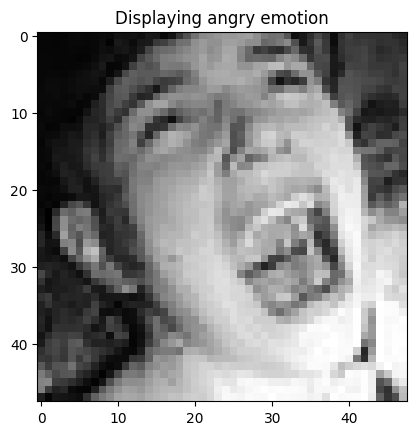

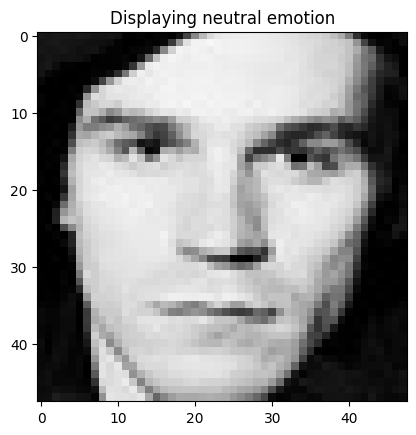

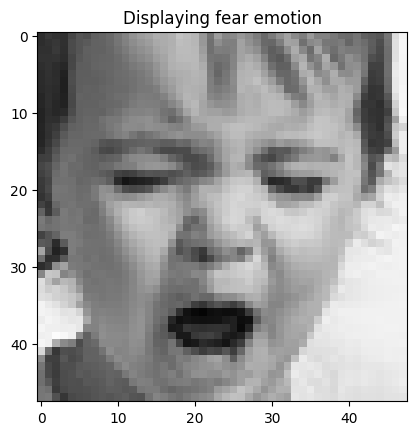

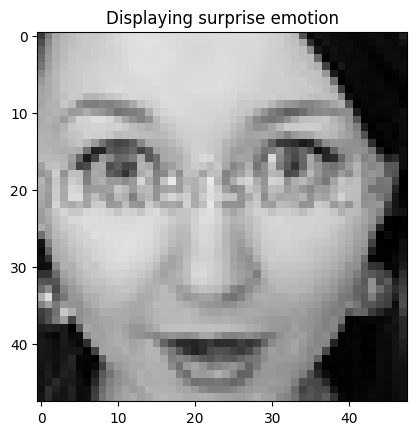

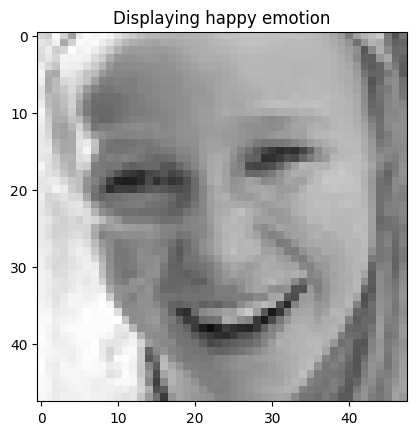

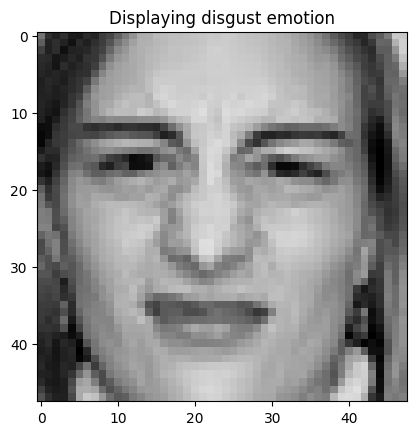

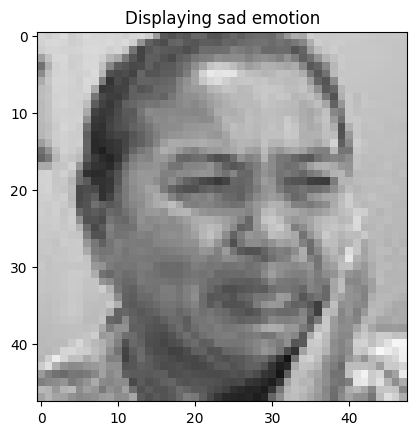

In [13]:
import glob

dataset_path = "/content/images/images/"
emotions = []
for file_name in glob.glob(dataset_path+'/train/*/*'):
    emotion = file_name.split('/')[-2]
    if emotion not in emotions:
        img = cv2.imread(file_name)
        plt.imshow(img)
        plt.title("Displaying {} emotion".format(emotion))
        plt.show()
    emotions.append(emotion)

## **Data Augmentation**

In [14]:
train_datagen = ImageDataGenerator(
    width_shift_range = 0.1,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.1,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,           # Directory containing the training data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "training"              # Uses the training subset of the data
)

validation_generator = validation_datagen.flow_from_directory(
    directory = test_dir,            # Directory containing the validation data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "validation"            # Uses the validation subset of the data
)

Found 23060 images belonging to 7 classes.
Found 1411 images belonging to 7 classes.


In [16]:
# Get the class indices (labels)
class_indices = train_generator.class_indices
print("Class Indices (Labels):", class_indices)

# Reverse the dictionary to get the class labels from indices
labels = {v: k for k, v in class_indices.items()}
print("Labels:", labels)

Class Indices (Labels): {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Labels: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [17]:
img_shape=train_generator.image_shape
img_shape

(48, 48, 1)

## **CNN Model Custom Architecture**

To create the CNN architecture, we'll start by specifying the input layer and the number of filters in the first convolutional layer. Then, we will add further convolutional layers with an increasing number of filters, followed by max-pooling layers to lower the spatial dimensions of the feature map. After the convolutional layers, we will classify the emotions using fully connected layers with ReLU activation.

To maximize model performance, we will experiment with different convolutional layer counts, filter sizes, and fully connected layers. In addition, we will employ techniques like dropout and batch normalization to reduce overfitting and increase the model's generalizability.




In [18]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf

# Define the input layer
inputs = Input(shape=(48, 48, 1), name='input_layer_2')

# Add a convolutional layer with 32 filters, 3x3 kernel size, and relu activation function
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
# Add a batch normalization layer
x = BatchNormalization()(x)

# Add a second convolutional layer with 64 filters, 3x3 kernel size, and relu activation function
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
# Add a second batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Add a third convolutional layer with 128 filters, 3x3 kernel size, and relu activation function
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
# Add a third batch normalization layer
x = BatchNormalization()(x)

# Add a fourth convolutional layer with 128 filters, 3x3 kernel size, and relu activation function
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
# Add a fourth batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Add a fifth convolutional layer with 256 filters, 3x3 kernel size, and relu activation function
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
# Add a fifth batch normalization layer
x = BatchNormalization()(x)

# Add a sixth convolutional layer with 256 filters, 3x3 kernel size, and relu activation function
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
# Add a sixth batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Flatten the output of the convolutional layers
x = Flatten()(x)
# Add a dense layer with 256 neurons and relu activation function
x = Dense(256, activation='relu')(x)

# Add a seventh batch normalization layer
x = BatchNormalization()(x)
# Add a dropout layer with 0.5 dropout rate
x = Dropout(0.5)(x)
# Add a dense layer with 7 neurons (one for each class) and softmax activation function
outputs = Dense(7, activation='softmax')(x)

# Define the model
model = Model(inputs=inputs, outputs=outputs)

# Print the model summary
model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 1,394,183 (5.32 MB)

 Trainable params: 1,391,943 (5.31 MB)

 Non-trainable params: 2,240 (8.75 KB)

## **Compiling CNN Model**

In [19]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
  )

In [20]:
epochs = 30
batch_size = 128

## CNN Model Training

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Lower the learning rate if accuracy stops improving.
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=8,
                                            verbose=1,
                                            factor=0.8,
                                            min_delta=1e-7,
                                            min_lr=1e-7)

# Define the filepath for saving the best model
model_checkpoint_path = 'best_model.h5'


early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Define the callback
checkpoint_callback = ModelCheckpoint(
    model_checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_list = [
    learning_rate_reduction,
    checkpoint_callback,
    early_stop
]



In [22]:
history = model.fit(x = train_generator,epochs = epochs,batch_size=batch_size,validation_data = validation_generator,callbacks=[callbacks_list])

Epoch 1/30
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1678 - loss: 2.9481
Epoch 1: val_accuracy improved from None to 0.16017, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.1836 - loss: 2.7715 - val_accuracy: 0.1602 - val_loss: 2.1173 - learning_rate: 1.0000e-04
Epoch 2/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2140 - loss: 2.4686
Epoch 2: val_accuracy improved from 0.16017 to 0.34656, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.2200 - loss: 2.4026 - val_accuracy: 0.3466 - val_loss: 1.7353 - learning_rate: 1.0000e-04
Epoch 3/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2448 - loss: 2.2731
Epoch 3: val_accuracy improved from 0.34656 to 0.34869, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.2531 - loss: 2.2238 - val_accuracy: 0.3487 - val_loss: 1.6969 - learning_rate: 1.0000e-04
Epoch 4/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2791 - loss: 2.1167
Epoch 4: val_accuracy improved from 0.34869 to 0.37633, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.2861 - loss: 2.0884 - val_accuracy: 0.3763 - val_loss: 1.5957 - learning_rate: 1.0000e-04
Epoch 5/30
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3032 - loss: 2.0041
Epoch 5: val_accuracy improved from 0.37633 to 0.39263, saving model to best_model.h5


...


Epoch 23: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.5383 - loss: 1.2283 - val_accuracy: 0.5712 - val_loss: 1.1282 - learning_rate: 1.0000e-04
Epoch 24/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5327 - loss: 1.2285
Epoch 24: val_accuracy did not improve from 0.57123
361/361 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.5379 - loss: 1.2187 - val_accuracy: 0.5656 - val_loss: 1.1359 - learning_rate: 1.0000e-04
Epoch 25/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5483 - loss: 1.1954
Epoch 25: val_accuracy improved from 0.57123 to 0.57902, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5479 - loss: 1.1923 - val_accuracy: 0.5790 - val_loss: 1.1111 - learning_rate: 1.0000e-04
Epoch 26/30
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5507 - loss: 1.1918
Epoch 26: val_accuracy improved from 0.57902 to 0.58257, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5532 - loss: 1.1922 - val_accuracy: 0.5826 - val_loss: 1.1156 - learning_rate: 1.0000e-04
Epoch 27/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5547 - loss: 1.1708
Epoch 27: val_accuracy improved from 0.58257 to 0.58611, saving model to best_model.h5



Epoch 27: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.5572 - loss: 1.1767 - val_accuracy: 0.5861 - val_loss: 1.1099 - learning_rate: 1.0000e-04
Epoch 28/30
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5617 - loss: 1.1602
Epoch 28: val_accuracy did not improve from 0.58611
361/361 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5632 - loss: 1.1615 - val_accuracy: 0.5826 - val_loss: 1.0985 - learning_rate: 1.0000e-04
Epoch 29/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5651 - loss: 1.1614
Epoch 29: val_accuracy improved from 0.58611 to 0.59036, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5670 - loss: 1.1549 - val_accuracy: 0.5904 - val_loss: 1.1140 - learning_rate: 1.0000e-04
Epoch 30/30
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5694 - loss: 1.1448
Epoch 30: val_accuracy did not improve from 0.59036
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5739 - loss: 1.1335 - val_accuracy: 0.5847 - val_loss: 1.1018 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 29.


## CNN Model Evaluation

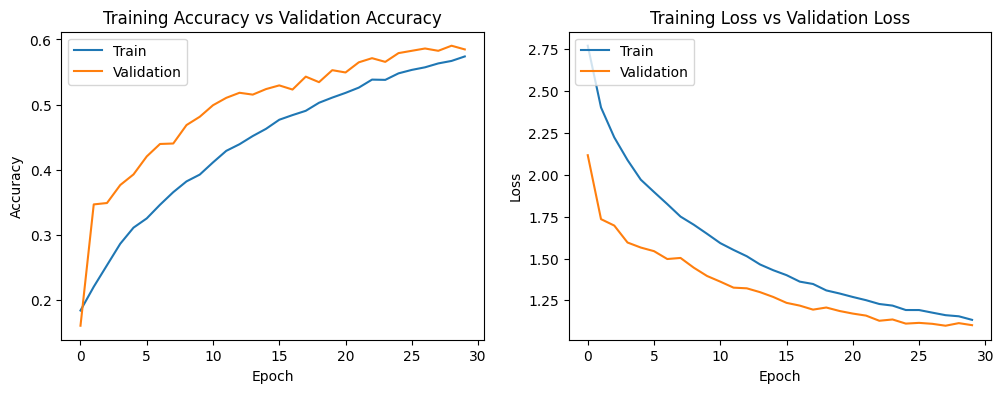

In [23]:
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

# Plot the train and validation accuracy
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

# Plot the train and validation Loss
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

**Confusion Matrix**


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


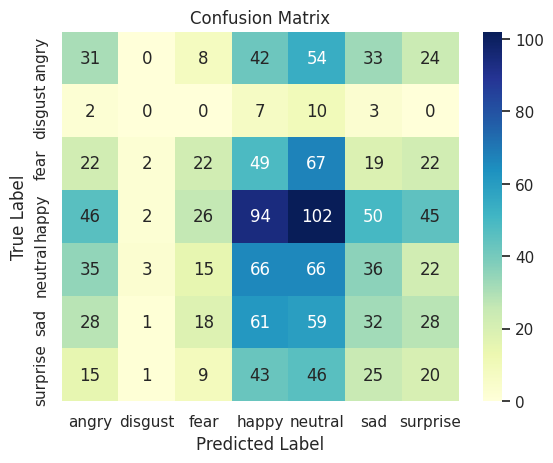

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_pred_probs = model.predict(validation_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
confusion_mtx = confusion_matrix(validation_labels, validation_pred_labels)
class_names = list(train_generator.class_indices.keys())
sns.set()
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [25]:
# Evaluate the model on training data
train_loss, train_accuracy = model.evaluate(train_generator, steps=len(train_generator))
print(f'Training Accuracy: {train_accuracy*100:.2f}%')

# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(validation_generator, steps=len(validation_generator))
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

361/361 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6017 - loss: 1.0529
Training Accuracy: 60.17%
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5904 - loss: 1.1140
Validation Accuracy: 59.04%


## Testing Random Validation Data

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


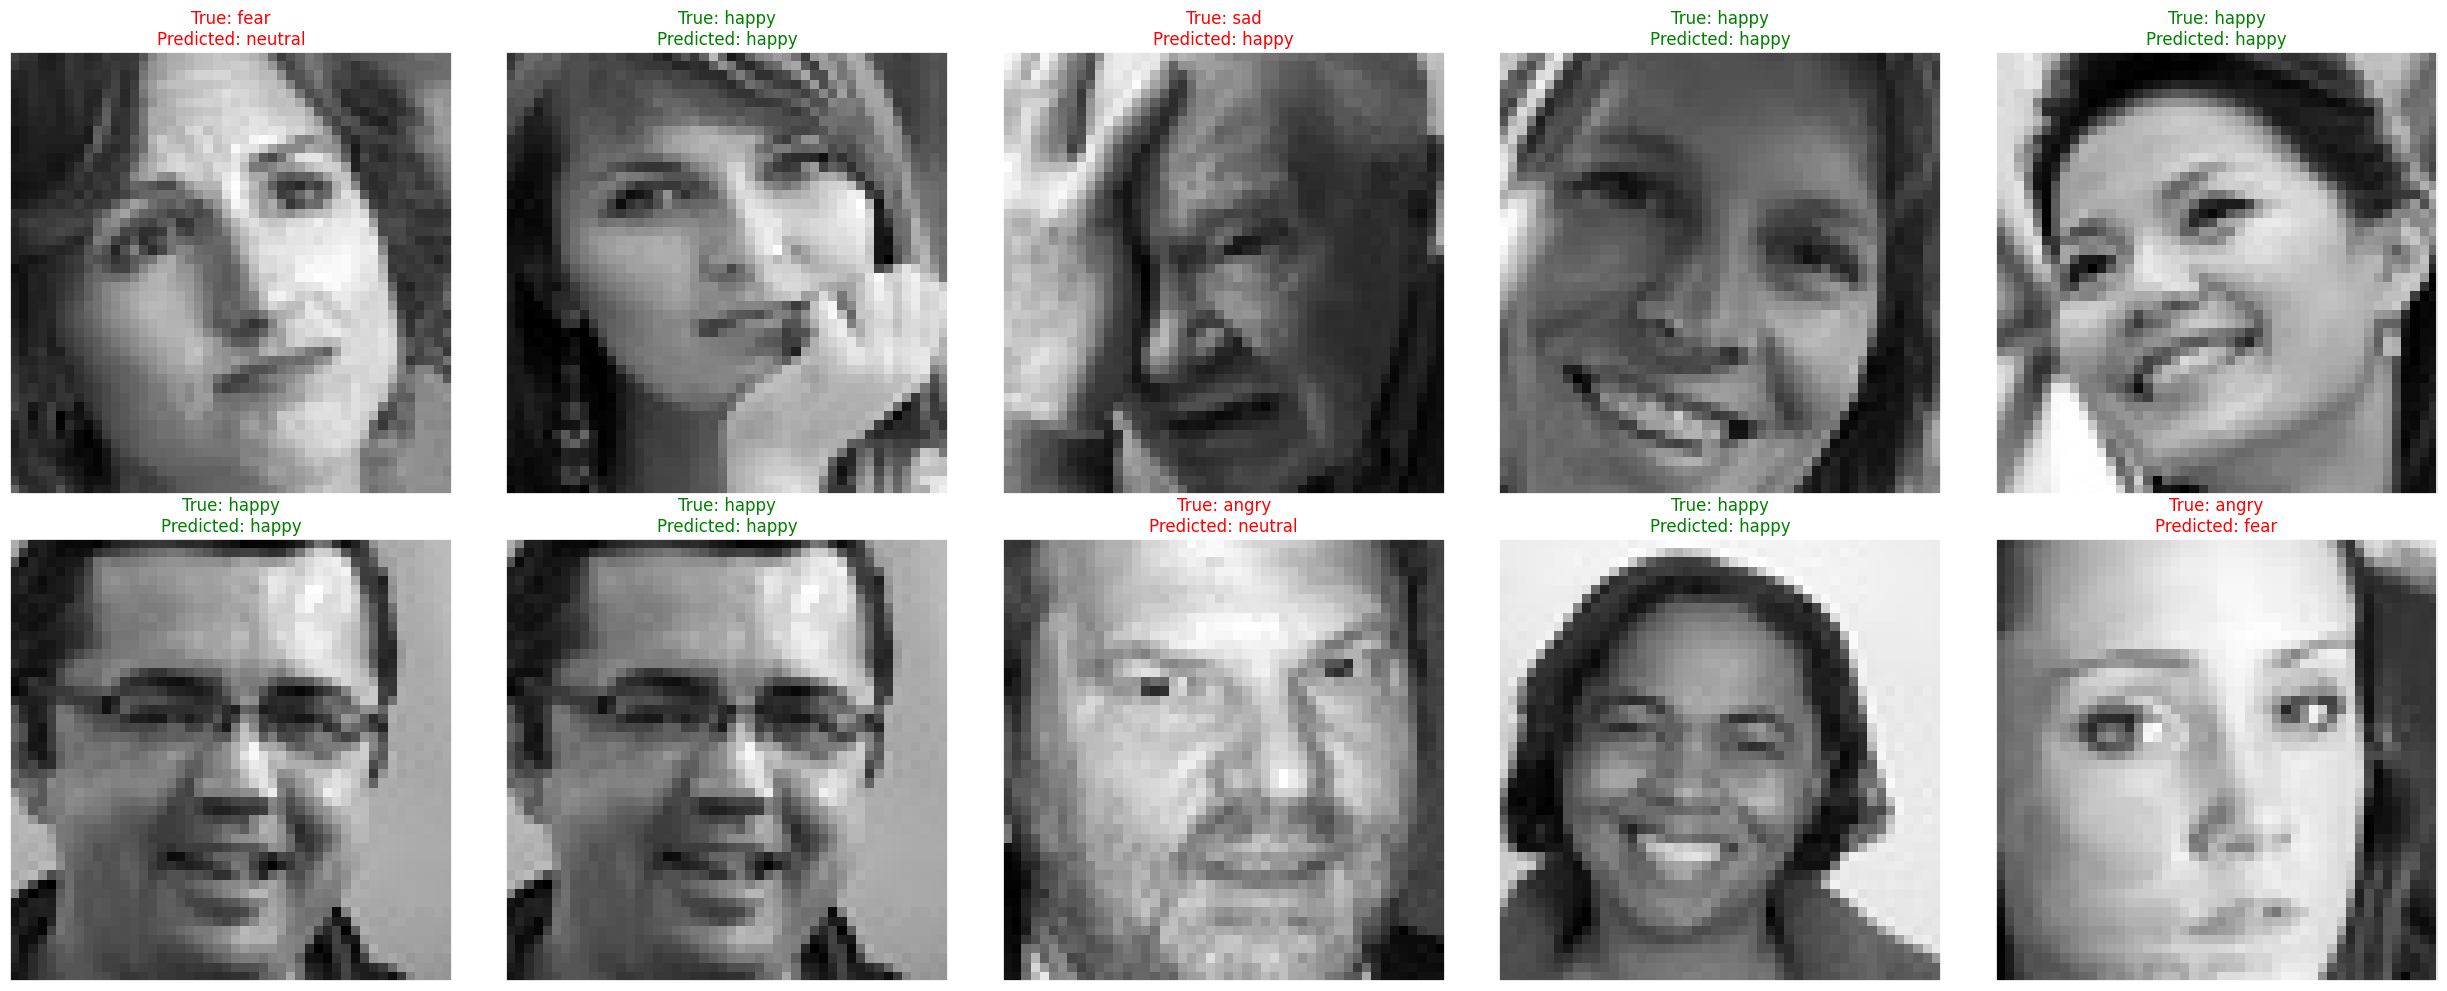

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define the emotion labels
labels = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}



# Get the batch size from the validation generator
batch_size = validation_generator.batch_size

# Generate random batch and image indices
random_batch = np.random.randint(0, len(validation_generator) - 1)
random_img_indices = np.random.randint(0, batch_size, 10)

# Create a plot
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    # Get a random image and its true label from the validation data
    random_img = validation_generator[random_batch][0][random_img_indices[i]]
    random_img_label = np.argmax(validation_generator[random_batch][1][random_img_indices[i]])
    print(type(random_img))
    # Predict the label using the model
    model_prediction = np.argmax(model.predict(tf.expand_dims(random_img, axis=0), verbose=0))

    # Display the image
    ax.imshow(random_img.squeeze(), cmap='gray')

    # Determine the color of the title (green if correct, red if incorrect)
    if labels[random_img_label] == labels[model_prediction]:
        color = "green"
    else:
        color = "red"

    # Set the title of the subplot
    ax.set_title(f"True: {labels[random_img_label]}\nPredicted: {labels[model_prediction]}", color=color)

# Show the plot
plt.tight_layout()
plt.show()


## Saving the Model

In [27]:
# Save the entire model
model.save('cnn_model_new_.h5')

In [28]:

import cv2

face_haar_cascade = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

## **Transfer Learning Using ResNet50V2 Model**

In [29]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 128

In [30]:
train_dir="/content/images/images/train"
test_dir="/content/images/images/validation"

## **Data Augmentation in ResNet50V2 Model**

In [31]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)


In [32]:
train_data = train_preprocessor.flow_from_directory(
    train_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size,
    subset='training',
)

test_data = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


## Fine-Tuning ResNet50V2

In [33]:
# 224,224,3
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )

ResNet50V2.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [34]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

## **Adding Custom Final Output Layers in ResNet50V2 Model**

In [35]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [36]:
ResNet50V2_Model = Create_ResNet50V2_Model()

ResNet50V2_Model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,996,295 (114.43 MB)

 Trainable params: 22,779,527 (86.90 MB)

 Non-trainable params: 7,216,768 (27.53 MB)

In [37]:
ResNet50V2_Model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [38]:
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping

# Create Callback Checkpoint
checkpoint_path = "ResNet50V2_Best_Model.h5"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True,mode='max',verbose=1)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 7, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.00005,
                                                  verbose=1)

callbacks = [Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = test_data.n // test_data.batch_size

## **Training the ResNet50V2 Model**

In [ ]:
ResNet50V2_history = ResNet50V2_Model.fit(train_data ,validation_data = test_data , epochs=15, batch_size=batch_size,
                                         callbacks = callbacks, steps_per_epoch=steps_per_epoch, validation_steps=validation_steps)

Epoch 1/15
 63/225 ━━━━━━━━━━━━━━━━━━━━ 4:58 2s/step - accuracy: 0.3041 - loss: 2.2098

## ResNet50V2 Model Evaluation

In [ ]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))

111/111 [==============================] - 21s 188ms/step - loss: 0.8606 - accuracy: 0.6984
    Test Loss: 0.86064
Test Accuracy: 69.84%


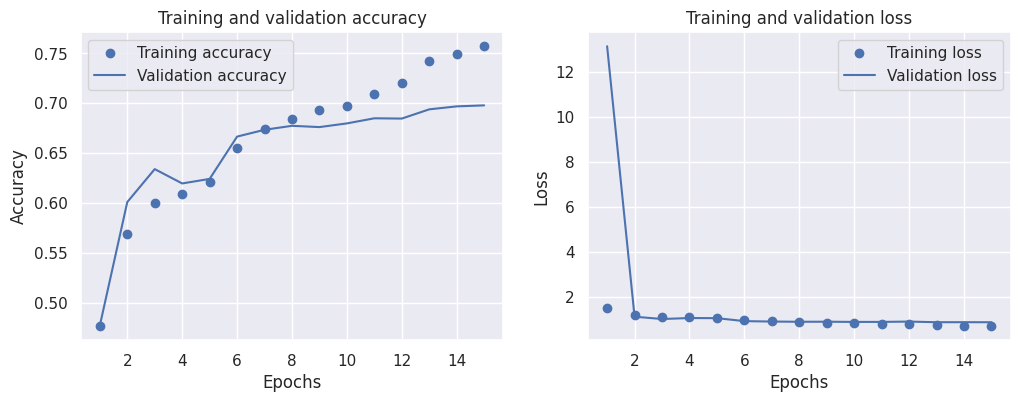

In [ ]:
import matplotlib.pyplot as plt

def plot_curves(history):
    """
    Plot training & validation accuracy and loss curves.

    Parameters:
    history (History): The history object returned by the fit method of a Keras model.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Assuming ResNet50V2_history is the history object returned by the fit method of a Keras model
plot_curves(ResNet50V2_history)


In [ ]:
ResNet50V2_Predictions = ResNet50V2_Model.predict(test_data)

# Choosing highest probalbilty class in every prediction
ResNet50V2_Predictions = np.argmax(ResNet50V2_Predictions, axis=1)

111/111 [==============================] - 19s 163ms/step


Text(0.5, 1.0, 'ResNet50V2 Confusion Matrix')

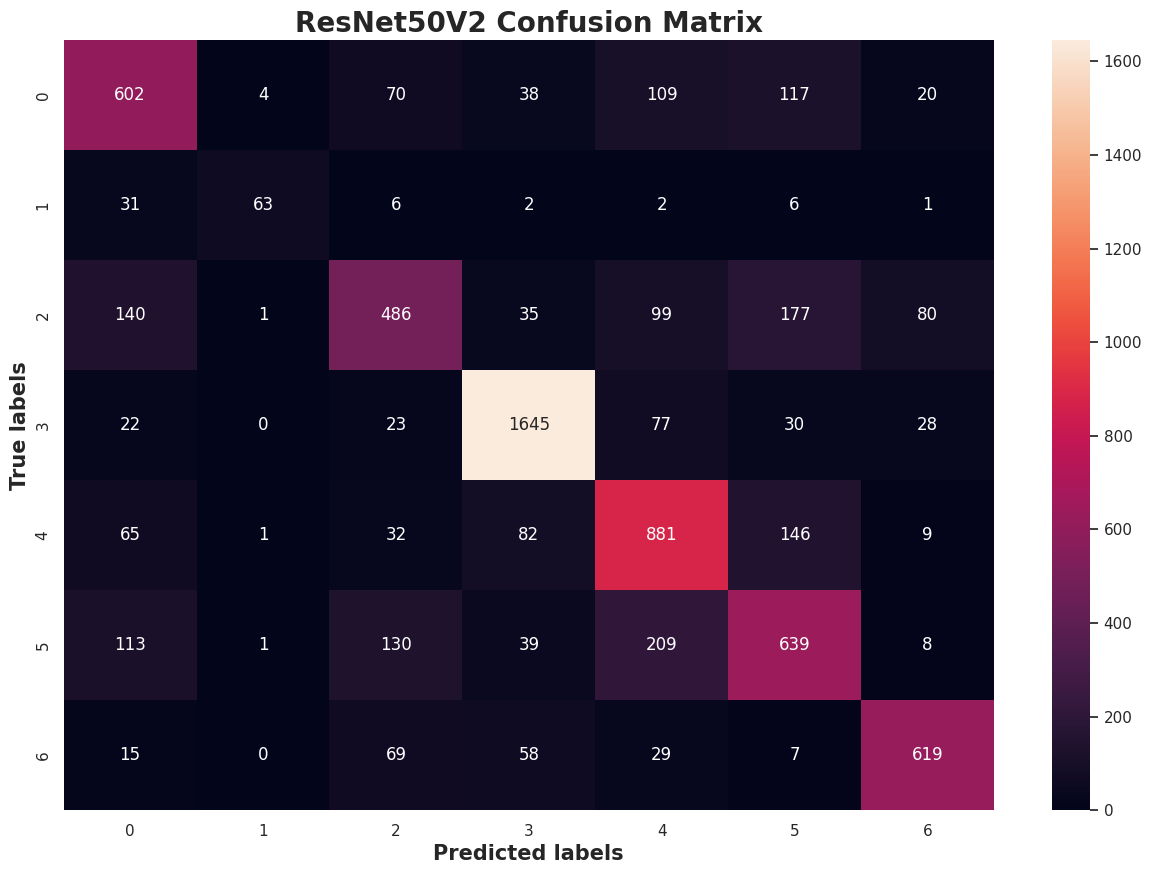

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig , ax= plt.subplots(figsize=(15,10))

cm=confusion_matrix(test_data.labels, ResNet50V2_Predictions)

sns.heatmap(cm, annot=True, fmt='g', ax=ax)

ax.set_xlabel('Predicted labels',fontsize=15, fontweight='bold')
ax.set_ylabel('True labels', fontsize=15, fontweight='bold')
ax.set_title('ResNet50V2 Confusion Matrix', fontsize=20, fontweight='bold')

## Testing Random Validation Data

In [ ]:
Emotion_Classes = ['Angry',
                  'Disgust',
                  'Fear',
                  'Happy',
                  'Neutral',
                  'Sad',
                  'Surprise']

In [ ]:
# Shuffling Test Data to show diffrent classes
test_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
    )

test_generator = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=True,
    batch_size=batch_size,
)

Found 7066 images belonging to 7 classes.


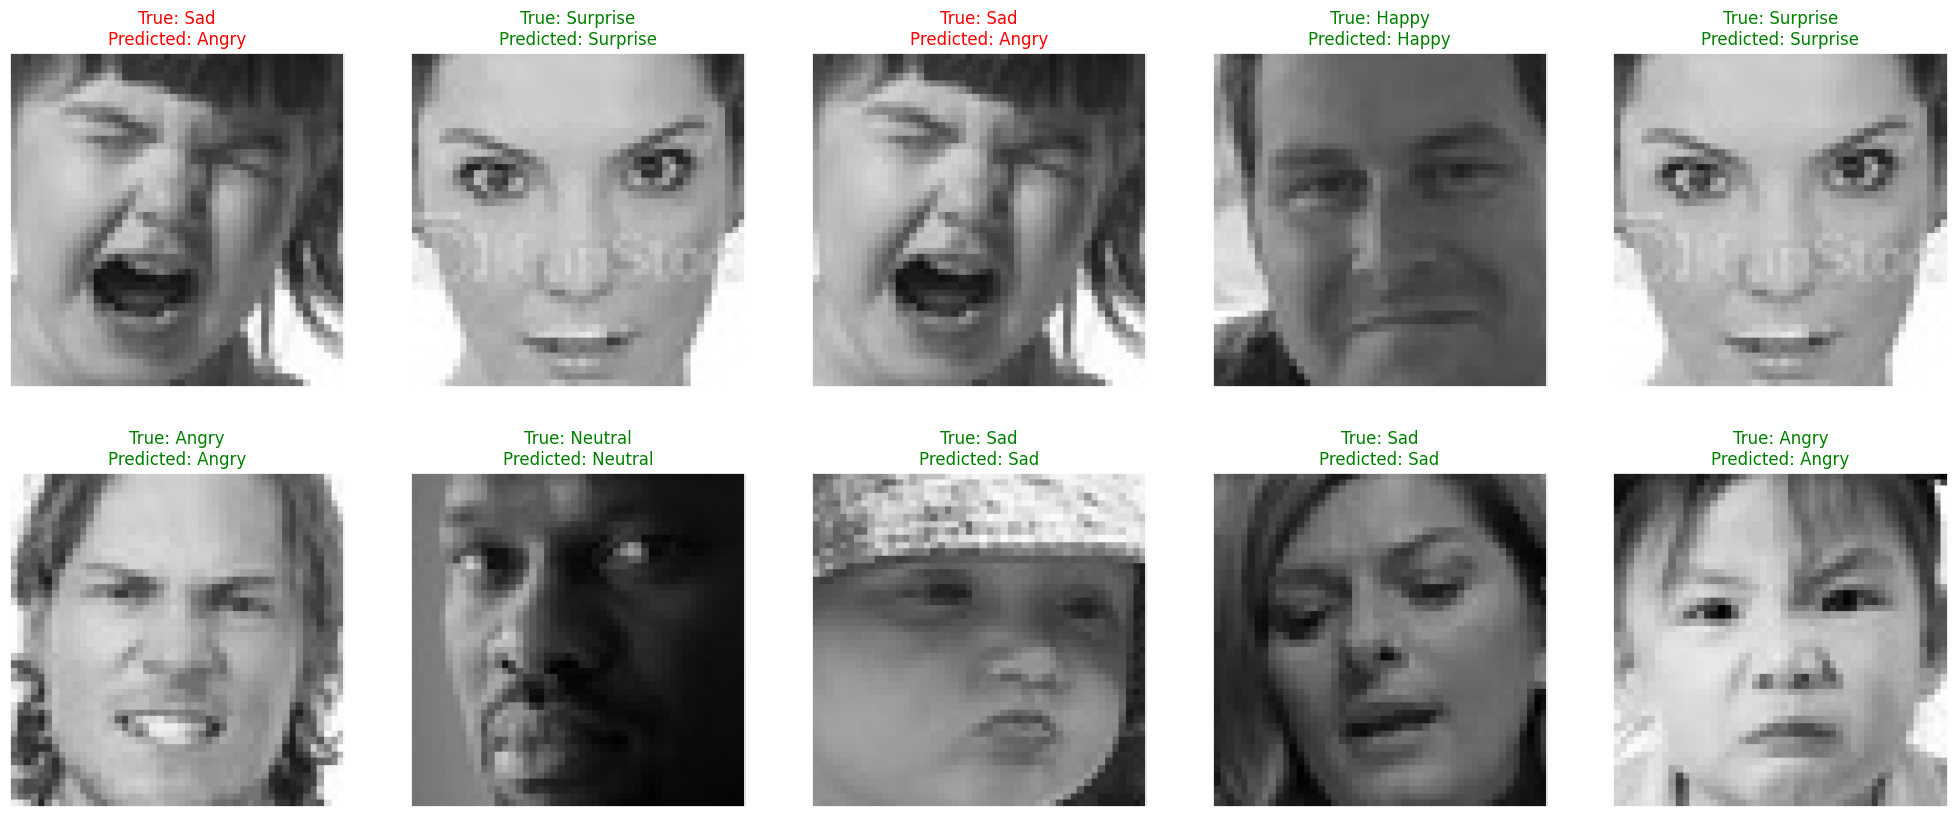

<Figure size 640x480 with 0 Axes>

In [ ]:
# Display 10 random pictures from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    Model_Prediction = np.argmax(ResNet50V2_Model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)
plt.show()
plt.tight_layout()


## Saving the ResNet50V2 Model

In [ ]:
ResNet50V2_Model.save("ResNet50V2_Model.h5")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
